# 设置

In [54]:
# 定义默认字体大小，让图表看起来更美观：
import matplotlib as mpl  # 导入matplotlib库
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot库

mpl.rcParams.update(mpl.rcParamsDefault)  # 重置matplotlib的配置参数为默认值
plt.style.use('default')  # 使用默认的绘图风格

# 设置全局字体大小为14
plt.rc('font', size=14)
# 设置坐标轴标签和标题的字体大小为14
plt.rc('axes', labelsize=14, titlesize=14)
# 设置图例的字体大小为14
plt.rc('legend', fontsize=14)
# 设置x轴刻度标签的字体大小为10
plt.rc('xtick', labelsize=10)
# 设置y轴刻度标签的字体大小为10
plt.rc('ytick', labelsize=10)

In [12]:
# 创建一个名为 `images/classification` 的文件夹（如果该文件夹尚不存在），并定义 `save_fig()` 函数，用于保存图片
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 第三章——分类

1. MNIST
2. 训练二元分类器

## 1. MNIST

MNIST数据集是由高中生和美国人口普查局的员工手写的70000个数字图像。每个图象都标有它代表的数字。

它通常呗称为机器学习的“hello world”

`Scikit-Learn`提供了许多帮助函数来下载流行的数据集。

`sklearn.datasets`包主要包含三种类型的函数：
1. `fetch_*`函数(例如`fetch_openml()`)用来下载现实生活中的数据集。作为`sklearn.utils.Bunch`对象返回。
2. `load_*`函数(例如`load_iris()`)用来加载与`Scikit-Learn`捆绑的小玩具数据集(因为它们不需要通过互联网下载)。作为`sklearn.utils.Bunch`对象返回。
3. `make_*`函数用来生成假数据，对测试很有用。生成的数据通常作为包含输入数据和目标的(X, y)元组返回，两者都是Numpy数组

`Bunch`对象是字典，其条目也可以作为属性返回，通常包含以下条目：
* `"DESCR"`: 数据集的描述。
* `"data"`: 输入数据，通常为二维Numpy数组。
* `"target"`: 标签，通常是一维Numpy数组。

In [10]:
# 找到当前环境下的缓存路径
from sklearn.datasets import get_data_home

print(get_data_home())

C:\Users\www12\scikit_learn_data


In [9]:
# 从OpenML.org获取MNIST数据集
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False,
                     data_home='F:\mywork\Hands-On Machine Learning\my-study\datasets\scikit_learn_data') # 显式修改指定缓存目录

---

补充：
1. 什么是`Bunch`对象？
    * Bunch是一个“**支持属性访问的字典**”，即1.Bunch是一个key-value容器；2.既可以像字典(`obj['data']`)一样访问；3.也可以像对象属性(`obj.data`)一样访问。（如下代码）
    * Bunch的本质是`dict`的子类，源码如下

    ```
    class Bunch(dict):
        def __init__(self, **kwargs):
            super().__init__(kwargs)
            self.__dict__ = self
    ```

   * 关键在于`self.__dict__ = self`，它使得`obj.data`等价于`obj['data']`
   * Bunch对象不强调行为(methods)，只强调**数据+元信息(意为理解数据的数据)+说明文档**的结构化封装
    * Bunch里面装着`ndarray`，而不是`DataFrame`，因为它不继承`Pandas`，它是一个轻量的数据集容器，它设计为`Numpy`原生类型

In [2]:
from sklearn.datasets import load_iris # 加载鸢尾花数据集，150个样本，每个样本4个特征，目标变量是3种鸢尾花的类别

iris = load_iris() # 此时iris为一个bunch对象
print(type(iris)) # sklearn.utils._bunch.Bunch

# 可以用两种方式访问数据，两种方式等价
iris['data']

<class 'sklearn.utils._bunch.Bunch'>


array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [4]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [45]:
iris.keys() # 列出bunch对象里的所有字段名

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [6]:
iris.DESCR # 元信息，即数据集的描述

'.. _iris_dataset:\n\nIris plants dataset\n--------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 150 (50 in each of three classes)\n:Number of Attributes: 4 numeric, predictive attributes and the class\n:Attribute Information:\n    - sepal length in cm\n    - sepal width in cm\n    - petal length in cm\n    - petal width in cm\n    - class:\n            - Iris-Setosa\n            - Iris-Versicolour\n            - Iris-Virginica\n\n:Summary Statistics:\n\n============== ==== ==== ======= ===== ====================\n                Min  Max   Mean    SD   Class Correlation\n============== ==== ==== ======= ===== ====================\nsepal length:   4.3  7.9   5.84   0.83    0.7826\nsepal width:    2.0  4.4   3.05   0.43   -0.4194\npetal length:   1.0  6.9   3.76   1.76    0.9490  (high!)\npetal width:    0.1  2.5   1.20   0.76    0.9565  (high!)\n============== ==== ==== ======= ===== ====================\n\n:Missing Attribute Values: None\n:Class Distribution: 

2. `fetch_openml()`有些特殊，它默认情况下是以`Pandas DataFrame`的形式返回输入，以`Pandas Series`的形式返回标签（除非数据集是稀疏的）。但是MNIST数据集包含图像，所以设置`as_frame=False`来获取Numpy数组形式的数据。

In [ ]:
# 当as_frame=True时的输入返回示例
mnist_frame = fetch_openml('mnist_784', as_frame=True,
                     data_home='F:\mywork\Hands-On Machine Learning\my-study\datasets\scikit_learn_data')

In [16]:
type(mnist_frame)

sklearn.utils._bunch.Bunch

In [17]:
type(mnist_frame.data)

pandas.core.frame.DataFrame

In [18]:
type(mnist_frame.target)

pandas.core.series.Series

In [19]:
type(mnist)

sklearn.utils._bunch.Bunch

In [20]:
type(mnist.data)

numpy.ndarray

In [21]:
type(mnist.target)

numpy.ndarray

---

看一下MNIST数据集中的data和target

In [44]:
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [33]:
X, y = mnist.data, mnist.target

In [37]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [46]:
X.shape

(70000, 784)

In [35]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

In [47]:
y.shape

(70000,)

可以看到有70000张图片，每张图片有784个特征。因为每个图像都是28×28像素，每个特征只代表一个像素的强度（从0（白色）到255（黑色））

看看数据集中的一个数字图片。需要获取一个实例的特征向量，将其变为28×28的数组，并使用Matplotlib的`imshow()`函数。使用`cmap=binary`来获得灰度颜色图。

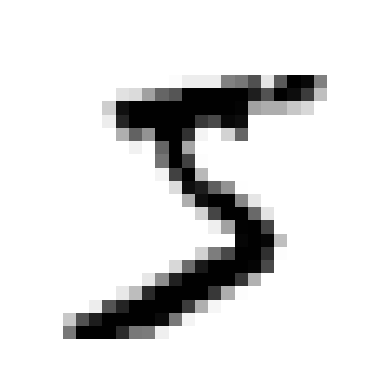

In [58]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)  # 一维向量 → 图像
    plt.imshow(image, cmap="binary")    # 用黑白色映射显示
    plt.axis("off")                     # 去掉无意义的坐标轴

some_digit = X[0]
plot_digit(some_digit)
plt.show()

---

补充：
1. cmap 是 colormap（颜色映射） 的缩写，用来规定：如何把“数值”映射成“颜色”
2. "binary"是黑白灰渐变色图。数值小 → 白色；数值大 → 黑色；中间值 → 灰度渐变
3. “binary”是“gray”的颜色相反操作（可尝试一下）
4. plt.axis() 用于控制：坐标轴显示范围与坐标轴是否可见。“off”为关闭坐标轴的所有可视元素

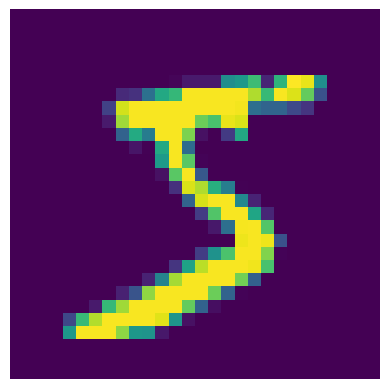

In [57]:
def plot_digit_grey(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="viridis")
    plt.axis("off")

some_digit = X[0]
plot_digit_grey(some_digit)
plt.show()

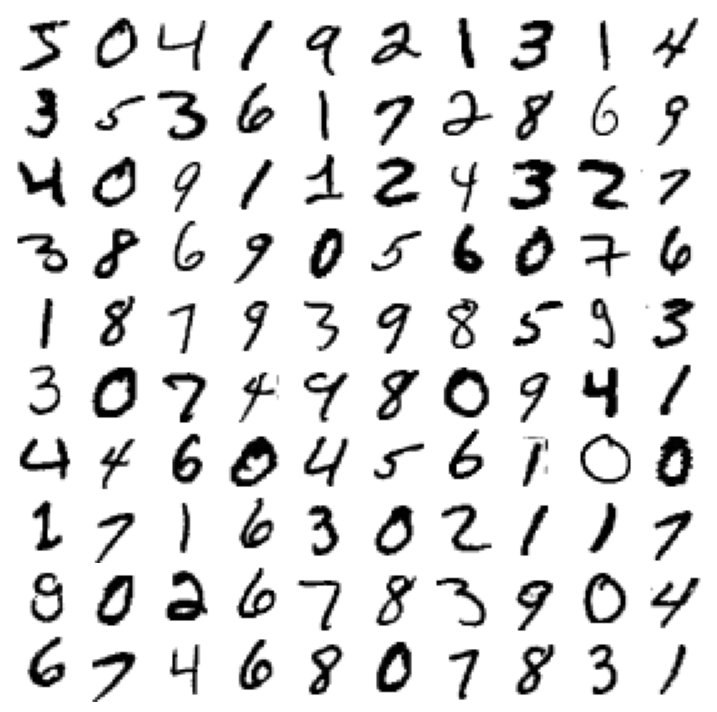

In [59]:
# 看看更多图像
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

**创建一个测试集**

`fetch_openml()`返回得MNIST数据集实际上已经是拆分为训练集（前60000个图像）和测试集（后10000个图像）

In [60]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

训练集已经在设计时就打乱了，这样保证了所有交叉验证折叠都是相似的。而且一些学习算法对训练实例的顺序很敏感，如果连续获得许多相似的实例，它们的性能就会很差（这句话不适用于时间序列数据）

## 2. 训练二元分类器

简化问题：只尝试识别一个数字————例如：识别数字5，二元分类四能够区分两个类：5和非5

In [69]:
# 首先，创建目标向量
y_train_5 = (y_train == '5') # 对于数字5，结果为真；对于其他数字，结果为假。
y_test_5 = (y_test == '5')

选择一个分类器并对其进行训练， 一个好的起点是使用Scikit-Learn的随机梯度下降（Stochastic Gradient Descent, SGD，或随机GD）分类器`SGDClassifier`类。该分类器能够有效地处理非常大的数据集。因为SGD独立处理训练实例，一次一个，这也使得SGD非常适合在线学习。

In [70]:
# 创建一个SGDClassifier并在整个训练集上训练
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [75]:
# 检测数字5的图像
sgd_clf.predict([X[35]])

array([ True])